# Notebook 11 — Ensemble: SVM+AG + LightGBM + KNN
**Desempenho Socioeconômico no ENEM (2012–2024)**

Treina três modelos base e combina via **VotingClassifier (hard + soft)**.

| Modelo base | Otimização | Treino |
|---|---|---|
| LinearSVC | AG (C, class_weight) | 800k |
| LightGBM | defaults balanceados | 800k |
| KNN | grid search k × métrica | 100k subset |

KNN usa subset de 100k porque KNN em 800k tornaria a predição inviável (~horas).
LinearSVC e LightGBM treinam no conjunto completo.

| Seção | Conteúdo |
|---|---|
| 0 | Setup |
| 1 | Carregamento 1M via DuckDB |
| 2 | Pré-processamento e split |
| 3 | LinearSVC + AG |
| 4 | LightGBM |
| 5 | KNN (grid search em subset) |
| 6 | Ensemble (hard + soft voting) |
| 7 | Comparação e figuras |
| 8 | Persistência |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import duckdb

try:
    import lightgbm as lgb
    print(f'LightGBM {lgb.__version__} OK')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'lightgbm'], check=True)
    import lightgbm as lgb
    print(f'LightGBM instalado: {lgb.__version__}')

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
N_SAMPLE     = 1_000_000
KNN_SUB      = 100_000   # KNN treina nesse subset (predição viável)

DATA_DIR   = '../data/processed'
MODELS_DIR = '../data/models'
FIGS_DIR   = DATA_DIR
PARQUET    = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# AG para LinearSVC
GA_POP=25; GA_GENS=20; GA_CXPB=0.70; GA_MUTPB=0.25
GA_TOUR=3; GA_ELITE=2; GA_SUB=50_000; GA_SUBV=10_000; GA_SEED=42
GENE_LO = np.array([-3.0, 0.0])
GENE_HI = np.array([ 2.0, 1.0])

print(f'N_SAMPLE={N_SAMPLE:,}  KNN_SUB={KNN_SUB:,}')

LightGBM 4.6.0 OK
N_SAMPLE=1,000,000  KNN_SUB=100,000


## Seção 1 — Carregamento 1M via DuckDB

In [2]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400','400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600','600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800','>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,}')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 277,460
  Baixo (<500): 145,077 (52.3%)
  Médio (500–700): 112,605 (40.6%)
  Alto (>700): 19,778 (7.1%)


## Seção 2 — Pré-processamento e Split

In [3]:
df['tp_sexo']   = df['TP_SEXO'].map({'F':0,'0':0,'M':1,'1':1})
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'],   errors='coerce')
df['q001']      = df['Q001'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q002']      = df['Q002'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q006']      = df['Q006_HARM'].map({c:i for i,c in enumerate('ABCDE')})
df['regiao']    = df['REGIAO'].map({'Norte':0,'Nordeste':1,'Centro-Oeste':2,'Sul':3,'Sudeste':4})
df['ano']       = df['NU_ANO'].astype('float32')

def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo','tp_cor','tp_escola','q001','q002','q006','regiao','ano']
FEATS_IDHM = [
    'idhm','idhm_educacao','idhm_renda','idhm_longevidade',
    'renda_percapita','tx_analfabetismo','tx_envelhecimento',
    'esperanca_vida','mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai','q_ocup_mae','q_n_pessoas','q_empregada',
    'q_carro','q_moto','q_geladeira','q_lavadora','q_tv',
    'q_computador','q_internet','q_celular','q_tipo_esc_em','q_bolsa_fam'
]
# M4 = conjunto completo usado pelo ensemble
FEATS_M2 = FEATS_BASE + FEATS_IDHM
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT

X = df[FEATS_M4].values.astype('float32')
y = df['y_mt'].values.astype('int8')
del df; gc.collect()

# 80/20 split
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
del X; gc.collect()

# Val set (20% do treino) para comparação de modelos
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.20, stratify=y_tr, random_state=RANDOM_STATE
)

# Subsets para AG e KNN
_, X_ag_tr, _, y_ag_tr = train_test_split(X_tr2, y_tr2, test_size=GA_SUB,  stratify=y_tr2, random_state=RANDOM_STATE)
_, X_ag_val,_, y_ag_val= train_test_split(X_val,  y_val,  test_size=GA_SUBV, stratify=y_val,  random_state=RANDOM_STATE)
_, X_knn,   _, y_knn   = train_test_split(X_tr2, y_tr2, test_size=KNN_SUB,  stratify=y_tr2, random_state=RANDOM_STATE)

print(f'Treino completo : {len(y_tr2):,}')
print(f'Validação       : {len(y_val):,}')
print(f'Teste [SELADO]  : {len(y_test):,}')
print(f'AG subset       : {len(y_ag_tr):,} treino / {len(y_ag_val):,} val')
print(f'KNN subset      : {len(y_knn):,}')
print(f'Features M4     : {len(FEATS_M4)} (base + IDHM + Q_EXT)')


Treino completo : 177,574
Validação       : 44,394
Teste [SELADO]  : 55,492
AG subset       : 50,000 treino / 10,000 val
KNN subset      : 100,000
Features M4     : 31 (base + IDHM + Q_EXT)


## Seção 3 — LinearSVC + AG

In [4]:
def decode_svm(ind):
    return (float(10**np.clip(ind[0], GENE_LO[0], GENE_HI[0])),
            bool(round(float(np.clip(ind[1], 0, 1)))))

def svm_fitness(ind, Xtr, Xv, ytr, yv):
    C, bal = decode_svm(ind)
    try:
        p = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler()),
                      ('svm', LinearSVC(C=C, class_weight='balanced' if bal else None,
                                        max_iter=2000, random_state=RANDOM_STATE))])
        p.fit(Xtr, ytr)
        return f1_score(yv, p.predict(Xv), average='macro')
    except Exception:
        return 0.0

def evolve_svm(Xtr, Xv, ytr, yv):
    rng  = np.random.default_rng(GA_SEED)
    pop  = np.column_stack([rng.uniform(GENE_LO[0], GENE_HI[0], GA_POP),
                             rng.integers(0,2,GA_POP).astype(float)])
    fits = np.array([svm_fitness(i, Xtr, Xv, ytr, yv) for i in pop])
    hist = [fits.max()]
    C0,b0 = decode_svm(pop[fits.argmax()])
    print(f'Gen  0 — best={fits.max():.4f}  C={C0:.4f}  bal={b0}')
    for gen in range(1, GA_GENS+1):
        elite   = list(pop[np.argsort(fits)[-GA_ELITE:]])
        new_pop = elite[:]
        while len(new_pop) < GA_POP:
            def tour(): idx=rng.integers(0,len(pop),GA_TOUR); return pop[idx[np.argmax(fits[idx])]].copy()
            p1,p2 = tour(),tour()
            if rng.random()<GA_CXPB:
                m=rng.random(2)<0.5; c1,c2=np.where(m,p1,p2),np.where(m,p2,p1)
            else: c1,c2=p1.copy(),p2.copy()
            for c in [c1,c2]:
                if rng.random()<GA_MUTPB:
                    if rng.random()<0.4: c[0]=np.clip(c[0]+rng.normal(0,0.6),GENE_LO[0],GENE_HI[0])
                    if rng.random()<0.3: c[1]=1-c[1]
            new_pop.append(c1)
            if len(new_pop)<GA_POP: new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([svm_fitness(i, Xtr, Xv, ytr, yv) for i in pop])
        hist.append(fits.max())
        Cb,bb=decode_svm(pop[fits.argmax()])
        print(f'Gen {gen:2d} — best={fits.max():.4f}  C={Cb:.4f}  bal={bb}  mean={fits.mean():.4f}')
    bi=fits.argmax()
    return pop[bi], fits[bi], hist

print('=== AG — LinearSVC ===')
t0 = time.time()
best_svm_ind, best_svm_fit, hist_svm = evolve_svm(X_ag_tr, X_ag_val, y_ag_tr, y_ag_val)
best_C, best_bal = decode_svm(best_svm_ind)
print(f'\nMelhor: C={best_C:.4f}, balanced={best_bal}  |  {(time.time()-t0)/60:.1f} min')

=== AG — LinearSVC ===
Gen  0 — best=0.4679  C=0.1786  bal=True
Gen  1 — best=0.4679  C=0.1786  bal=True  mean=0.4500
Gen  2 — best=0.4679  C=0.1786  bal=True  mean=0.4534
Gen  3 — best=0.4679  C=0.1786  bal=True  mean=0.4534
Gen  4 — best=0.4679  C=0.1786  bal=True  mean=0.4678
Gen  5 — best=0.4679  C=0.1786  bal=True  mean=0.4620
Gen  6 — best=0.4679  C=0.1786  bal=True  mean=0.4649
Gen  7 — best=0.4679  C=0.1786  bal=True  mean=0.4678
Gen  8 — best=0.4679  C=0.1786  bal=True  mean=0.4620
Gen  9 — best=0.4679  C=0.1786  bal=True  mean=0.4620
Gen 10 — best=0.4679  C=0.1786  bal=True  mean=0.4678
Gen 11 — best=0.4683  C=0.0406  bal=True  mean=0.4678
Gen 12 — best=0.4683  C=0.0406  bal=True  mean=0.4650
Gen 13 — best=0.4683  C=0.0406  bal=True  mean=0.4680
Gen 14 — best=0.4683  C=0.0406  bal=True  mean=0.4653
Gen 15 — best=0.4683  C=0.0406  bal=True  mean=0.4624
Gen 16 — best=0.4683  C=0.0406  bal=True  mean=0.4624
Gen 17 — best=0.4683  C=0.0406  bal=True  mean=0.4653
Gen 18 — best=0.46

In [5]:
# Treino final LinearSVC nos 640k
pipe_svm = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('svm', LinearSVC(C=best_C, class_weight='balanced' if best_bal else None,
                      max_iter=2000, random_state=RANDOM_STATE))
])
pipe_svm.fit(X_tr2, y_tr2)
yp_svm = pipe_svm.predict(X_val)
svm_f1 = f1_score(y_val, yp_svm, average='macro')
print(f'LinearSVC+AG — Macro F1: {svm_f1:.4f}')
print(classification_report(y_val, yp_svm, target_names=FAIXA_ORDER))

LinearSVC+AG — Macro F1: 0.4738
                 precision    recall  f1-score   support

   Baixo (<500)       0.65      0.73      0.69     23213
Médio (500–700)       0.51      0.31      0.39     18017
    Alto (>700)       0.25      0.56      0.35      3164

       accuracy                           0.55     44394
      macro avg       0.47      0.53      0.47     44394
   weighted avg       0.56      0.55      0.54     44394



## Seção 4 — LightGBM

In [6]:
pipe_lgb = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1
    ))
])

print('Treinando LightGBM...')
t0 = time.time()
pipe_lgb.fit(X_tr2, y_tr2)
yp_lgb = pipe_lgb.predict(X_val)
lgb_f1 = f1_score(y_val, yp_lgb, average='macro')
print(f'LightGBM — Macro F1: {lgb_f1:.4f}  |  {(time.time()-t0):.1f}s')
print(classification_report(y_val, yp_lgb, target_names=FAIXA_ORDER))

Treinando LightGBM...
LightGBM — Macro F1: 0.5149  |  36.7s
                 precision    recall  f1-score   support

   Baixo (<500)       0.71      0.68      0.69     23213
Médio (500–700)       0.53      0.41      0.46     18017
    Alto (>700)       0.27      0.71      0.39      3164

       accuracy                           0.57     44394
      macro avg       0.50      0.60      0.51     44394
   weighted avg       0.61      0.57      0.58     44394



## Seção 5 — KNN (grid search em subset 100k)

KNN armazena todos os pontos de treino para predição — inviável em 640k.
Treinamos num subset de 100k e incluímos no ensemble.

In [7]:
K_GRID      = [5, 7, 11, 21]
METRIC_GRID = ['euclidean', 'manhattan']

print('Grid search KNN (subset 100k):')
print(f'{"k":>4s}  {"metric":>12s}  {"Macro F1":>9s}')
print('-' * 32)

best_knn_f1, best_k, best_metric = 0, None, None
for metric in METRIC_GRID:
    for k in K_GRID:
        pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=1))
        ])
        pipe.fit(X_knn, y_knn)
        f1 = f1_score(y_val, pipe.predict(X_val), average='macro')
        print(f'{k:>4d}  {metric:>12s}  {f1:>9.4f}')
        if f1 > best_knn_f1:
            best_knn_f1, best_k, best_metric = f1, k, metric

print(f'\nMelhor KNN: k={best_k}, metric={best_metric}  →  F1={best_knn_f1:.4f}')

pipe_knn = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, n_jobs=1))
])
pipe_knn.fit(X_knn, y_knn)
yp_knn = pipe_knn.predict(X_val)
print(classification_report(y_val, yp_knn, target_names=FAIXA_ORDER))

Grid search KNN (subset 100k):
   k        metric   Macro F1
--------------------------------
   5     euclidean     0.4599
   7     euclidean     0.4655
  11     euclidean     0.4696
  21     euclidean     0.4711
   5     manhattan     0.4633
   7     manhattan     0.4712
  11     manhattan     0.4768
  21     manhattan     0.4767

Melhor KNN: k=11, metric=manhattan  →  F1=0.4768
                 precision    recall  f1-score   support

   Baixo (<500)       0.65      0.75      0.69     23213
Médio (500–700)       0.53      0.49      0.51     18017
    Alto (>700)       0.43      0.15      0.23      3164

       accuracy                           0.60     44394
      macro avg       0.54      0.46      0.48     44394
   weighted avg       0.59      0.60      0.59     44394



## Seção 6 — Ensemble

**Hard voting**: cada modelo vota na classe, vence a maioria.

**Soft voting**: média das probabilidades. LinearSVC não tem predict_proba nativo —
usamos `CalibratedClassifierCV` (Platt scaling) para obter probabilidades calibradas.

In [8]:
# Hard voting
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[
        ('svm', pipe_svm),
        ('lgb', pipe_lgb),
        ('knn', pipe_knn),
    ],
    voting='hard'
)
# VotingClassifier.fit() re-treina internamente — usamos predict direto com modelos já treinados
# via predição manual para evitar re-treino
preds_hard = np.stack([yp_svm, yp_lgb, yp_knn], axis=1)  # shape: (n, 3 modelos)
yp_hard = np.apply_along_axis(
    lambda row: np.bincount(row.astype(int), minlength=3).argmax(),
    axis=1, arr=preds_hard
)
hard_f1 = f1_score(y_val, yp_hard, average='macro')
print(f'Ensemble Hard Voting — Macro F1: {hard_f1:.4f}')
print(classification_report(y_val, yp_hard, target_names=FAIXA_ORDER))

Ensemble Hard Voting — Macro F1: 0.5142
                 precision    recall  f1-score   support

   Baixo (<500)       0.66      0.76      0.71     23213
Médio (500–700)       0.54      0.38      0.44     18017
    Alto (>700)       0.31      0.53      0.39      3164

       accuracy                           0.59     44394
      macro avg       0.51      0.56      0.51     44394
   weighted avg       0.59      0.59      0.58     44394



In [9]:
# Soft voting — probabilidades de cada modelo
# LinearSVC não tem predict_proba; usamos decision_function + softmax como proxy
from scipy.special import softmax as _softmax

def svm_proba(pipe, X):
    scores = pipe.decision_function(X)   # shape (n, n_classes)
    return _softmax(scores, axis=1)

prob_svm  = svm_proba(pipe_svm, X_val)
prob_lgb  = pipe_lgb.predict_proba(X_val)
prob_knn  = pipe_knn.predict_proba(X_val)

prob_soft = (prob_svm + prob_lgb + prob_knn) / 3
yp_soft   = prob_soft.argmax(axis=1)
soft_f1   = f1_score(y_val, yp_soft, average='macro')
print(f'Ensemble Soft Voting — Macro F1: {soft_f1:.4f}')
print(classification_report(y_val, yp_soft, target_names=FAIXA_ORDER))

Ensemble Soft Voting — Macro F1: 0.5334
                 precision    recall  f1-score   support

   Baixo (<500)       0.68      0.74      0.71     23213
Médio (500–700)       0.55      0.44      0.49     18017
    Alto (>700)       0.34      0.49      0.40      3164

       accuracy                           0.60     44394
      macro avg       0.52      0.56      0.53     44394
   weighted avg       0.60      0.60      0.60     44394



## Seção 7 — Comparação e Figuras

In [10]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr2, y_tr2)
yp_dummy = dummy.predict(X_val)

modelos = [
    ('Baseline (majority)', yp_dummy),
    (f'KNN  (k={best_k}, {best_metric}, 100k)', yp_knn),
    (f'LinearSVC+AG (C={best_C:.3f})', yp_svm),
    ('LightGBM (500 est.)', yp_lgb),
    ('Ensemble Hard Voting', yp_hard),
    ('Ensemble Soft Voting', yp_soft),
]

rows = []
for nome, yp in modelos:
    rows.append([
        nome,
        accuracy_score(y_val, yp),
        f1_score(y_val, yp, average='macro'),
        f1_score(y_val, yp, average='weighted'),
    ])
df_res = pd.DataFrame(rows, columns=['Modelo','Accuracy','Macro F1','Weighted F1'])
print('=== Comparação Geral — FAIXA_MT 3 classes (validation set) ===')
print(df_res.to_string(index=False))

=== Comparação Geral — FAIXA_MT 3 classes (validation set) ===
                      Modelo  Accuracy  Macro F1  Weighted F1
         Baseline (majority)  0.522886  0.228901     0.359068
KNN  (k=11, manhattan, 100k)  0.599495  0.476802     0.585739
      LinearSVC+AG (C=0.041)  0.549511  0.473813     0.540433
         LightGBM (500 est.)  0.571023  0.514911     0.577989
        Ensemble Hard Voting  0.586566  0.514186     0.578174
        Ensemble Soft Voting  0.603054  0.533407     0.599530


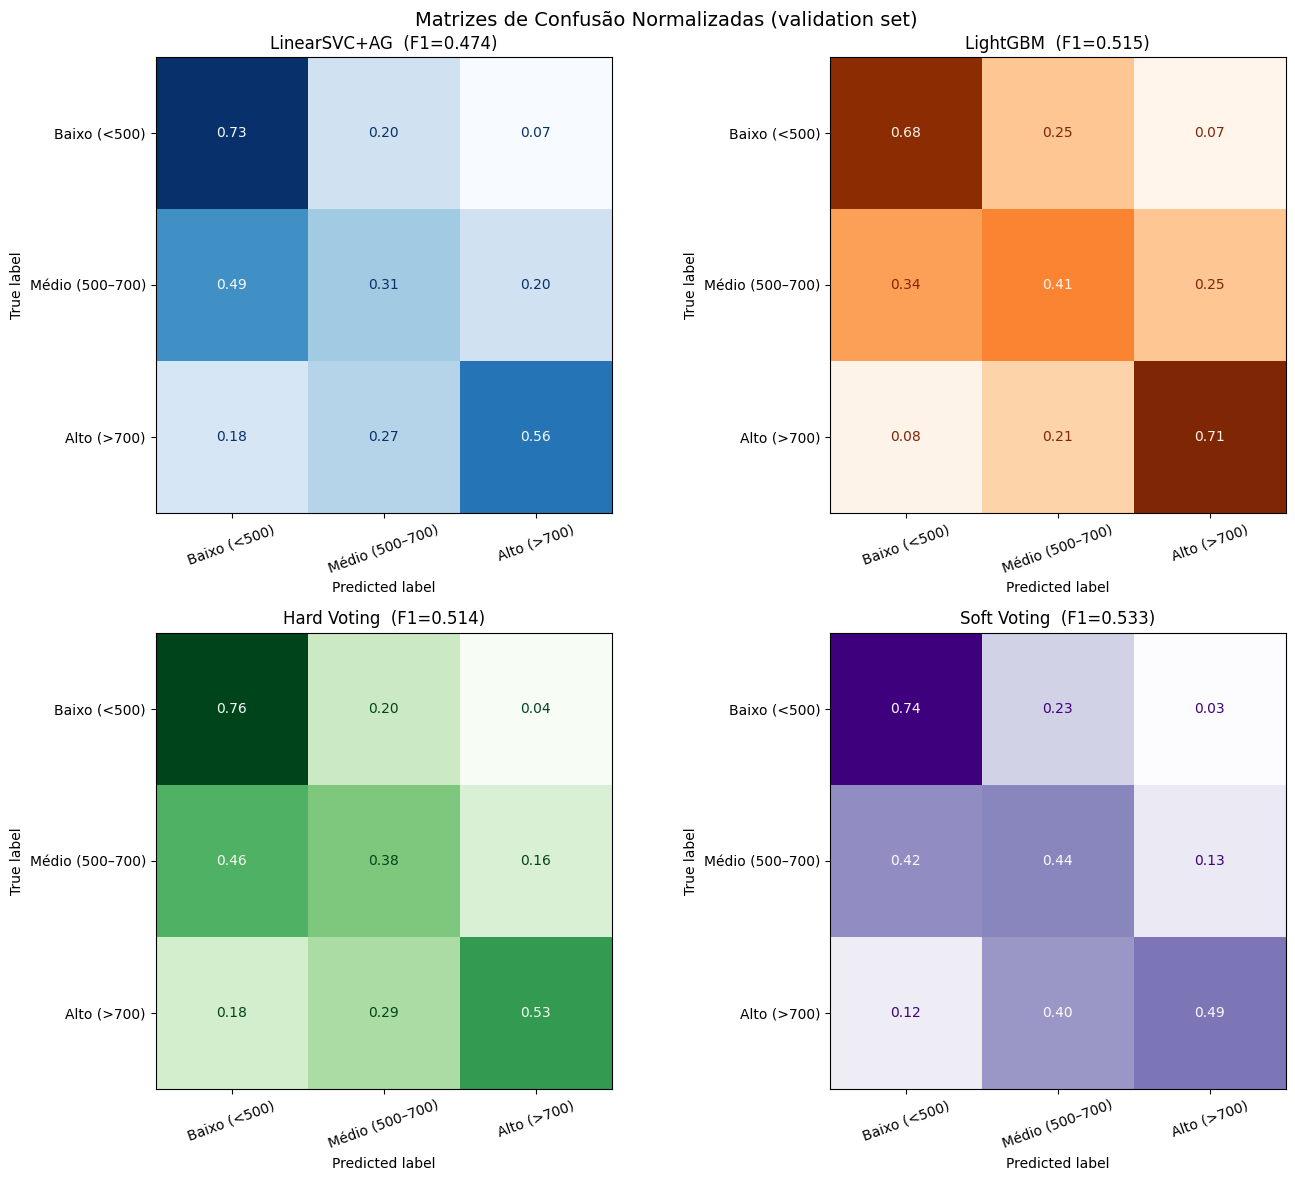

Salvo: fig_11_cm.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pares = [
    (yp_svm,  f'LinearSVC+AG  (F1={svm_f1:.3f})',  'Blues'),
    (yp_lgb,  f'LightGBM  (F1={lgb_f1:.3f})',       'Oranges'),
    (yp_hard, f'Hard Voting  (F1={hard_f1:.3f})',    'Greens'),
    (yp_soft, f'Soft Voting  (F1={soft_f1:.3f})',    'Purples'),
]
for ax, (yp, title, cmap) in zip(axes.flat, pares):
    cm = confusion_matrix(y_val, yp, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER).plot(
        ax=ax, cmap=cmap, colorbar=False, values_format='.2f'
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Matrizes de Confusão Normalizadas (validation set)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_11_cm.png', dpi=150)
plt.show()
print('Salvo: fig_11_cm.png')

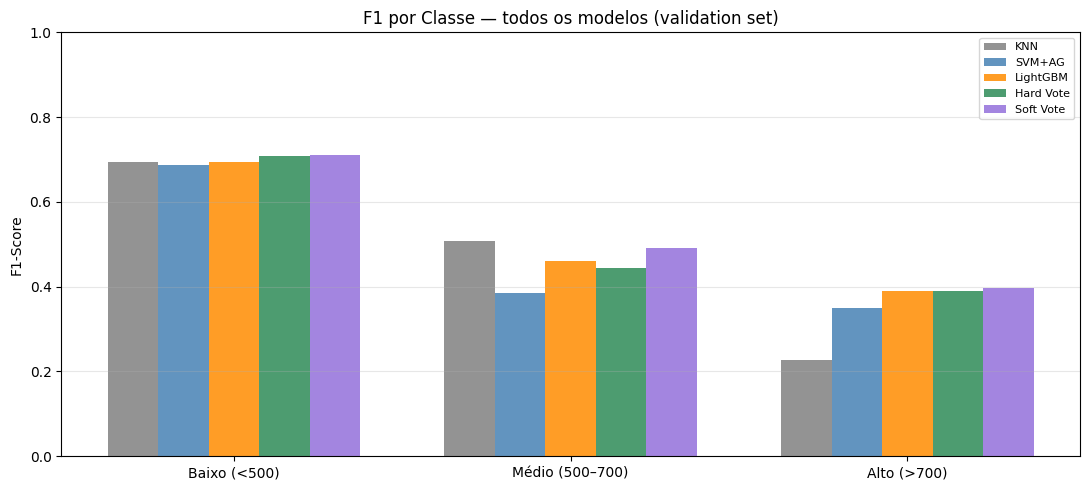

Salvo: fig_11_f1_classe.png


In [12]:
modelos_plot = [
    ('KNN', yp_knn, 'gray'),
    ('SVM+AG', yp_svm, 'steelblue'),
    ('LightGBM', yp_lgb, 'darkorange'),
    ('Hard Vote', yp_hard, 'seagreen'),
    ('Soft Vote', yp_soft, 'mediumpurple'),
]
n_mod = len(modelos_plot)
x = np.arange(3)
w = 0.15
fig, ax = plt.subplots(figsize=(11, 5))
for i, (nome, yp, cor) in enumerate(modelos_plot):
    f1s = f1_score(y_val, yp, average=None, labels=[0,1,2])
    ax.bar(x + (i - n_mod/2 + 0.5)*w, f1s, w, label=nome, color=cor, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('F1 por Classe — todos os modelos (validation set)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_11_f1_classe.png', dpi=150)
plt.show()
print('Salvo: fig_11_f1_classe.png')

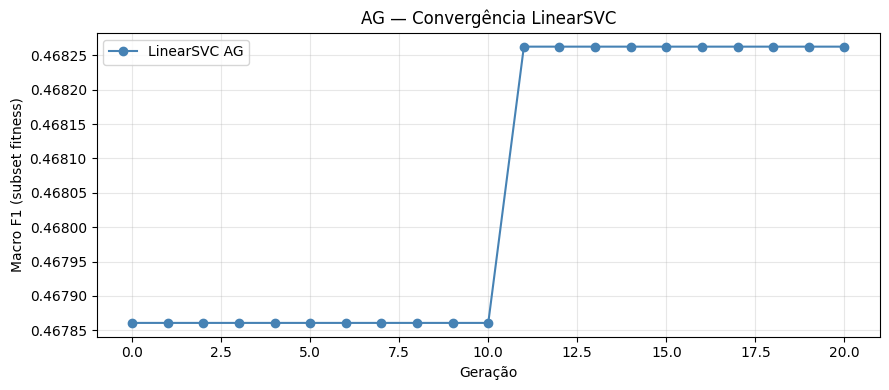

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(hist_svm)), hist_svm, 'o-', color='steelblue', label='LinearSVC AG')
ax.set_xlabel('Geração')
ax.set_ylabel('Macro F1 (subset fitness)')
ax.set_title('AG — Convergência LinearSVC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_11_ag_convergencia.png', dpi=150)
plt.show()

## Seção 8 — Persistência

In [14]:
joblib.dump(pipe_svm, f'{MODELS_DIR}/ens_svm_ag.pkl')
joblib.dump(pipe_lgb, f'{MODELS_DIR}/ens_lgb.pkl')
joblib.dump(pipe_knn, f'{MODELS_DIR}/ens_knn.pkl')
joblib.dump({
    'test': {'X_m2': X_test, 'y': y_test},
    'feats_m2': FEATS_M2,
    'ag_history': hist_svm,
    'results': df_res,
}, f'{MODELS_DIR}/ensemble_results.pkl')

print('Salvos em data/models/:')
for f in ['ens_svm_ag.pkl', 'ens_lgb.pkl', 'ens_knn.pkl', 'ensemble_results.pkl']:
    print(f'  {f}')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))

Salvos em data/models/:
  ens_svm_ag.pkl
  ens_lgb.pkl
  ens_knn.pkl
  ensemble_results.pkl

=== RESUMO FINAL ===
                      Modelo  Accuracy  Macro F1  Weighted F1
         Baseline (majority)  0.522886  0.228901     0.359068
KNN  (k=11, manhattan, 100k)  0.599495  0.476802     0.585739
      LinearSVC+AG (C=0.041)  0.549511  0.473813     0.540433
         LightGBM (500 est.)  0.571023  0.514911     0.577989
        Ensemble Hard Voting  0.586566  0.514186     0.578174
        Ensemble Soft Voting  0.603054  0.533407     0.599530
